### CNN model with the Mel spectogram 

In [20]:
import pandas as pd
import numpy as np
import librosa as lb
import soundfile as sf
import matplotlib.pyplot as plt
import sys
from pathlib import Path

In [2]:
sys.path.append(str(Path().resolve().parents[0]))

In [3]:
from smart_stethoscope.ml_logic.data_loading import load_data
from smart_stethoscope.ml_logic.preprocessing import (
    extract_mfcc_features,
    preprocess_tabular_data
)
from smart_stethoscope.ml_logic.model import run_logistic_baseline

In [4]:
df = load_data()

df.shape


✅ Processed audio files already exist, skipping extraction

Load data from cached CSV...


(6898, 13)

In [5]:
df.head()

,start,end,crackles,wheezes,filename,chest_location,cycle_filename,disease,age,sex,adult_bmi,child_weight,child_height
0,1.377,4.249,1,0,172_2b5_Pl_mc_AKGC417L,Pl,172_2b5_Pl_mc_AKGC417L_0,COPD,73.0,M,29.3,NaN,NaN
1,4.249,7.387,1,0,172_2b5_Pl_mc_AKGC417L,Pl,172_2b5_Pl_mc_AKGC417L_1,COPD,73.0,M,29.3,NaN,NaN
2,7.387,10.175,1,0,172_2b5_Pl_mc_AKGC417L,Pl,172_2b5_Pl_mc_AKGC417L_2,COPD,73.0,M,29.3,NaN,NaN
3,10.175,12.897,0,0,172_2b5_Pl_mc_AKGC417L,Pl,172_2b5_Pl_mc_AKGC417L_3,COPD,73.0,M,29.3,NaN,NaN
4,12.897,15.634,0,0,172_2b5_Pl_mc_AKGC417L,Pl,172_2b5_Pl_mc_AKGC417L_4,COPD,73.0,M,29.3,NaN,NaN


In [6]:
X_train_tab, X_test_tab, y_train, y_test, train_pids, test_pids = preprocess_tabular_data(df)

/home/sunil/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [9]:
X_train_tab

,crackles,wheezes,filename,age,sex,chest_location_Al,chest_location_Ar,chest_location_Ll,chest_location_Lr,chest_location_Pl,chest_location_Pr,chest_location_Tc,cycle_length,bmi
0,1,0,172_2b5_Pl_mc_AKGC417L,0.487425,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.124455,0.546931
1,1,0,172_2b5_Pl_mc_AKGC417L,0.487425,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.348815,0.546931
2,1,0,172_2b5_Pl_mc_AKGC417L,0.487425,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.053605,0.546931
3,0,0,172_2b5_Pl_mc_AKGC417L,0.487425,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.002064,0.546931
4,0,0,172_2b5_Pl_mc_AKGC417L,0.487425,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.010588,0.546931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5801,0,0,107_2b5_Pl_mc_AKGC417L,0.576555,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.299805,1.306276
5802,0,0,107_2b5_Pl_mc_AKGC417L,0.576555,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.128583,1.306276
5803,0,0,107_2b5_Pl_mc_AKGC417L,0.576555,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.159790,1.306276
5804,0,0,107_2b5_Pl_mc_AKGC417L,0.576555,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.148826,1.306276


In [17]:
cycle_audio_path = "/home/sunil/code/mi-mi-mia/smart-stethoscope/preprocessed_data/padded_audio_breathing_cycles"
train_pids_df = pd.DataFrame({'cycle_filename':train_pids})
train_pids_df.cycle_filename[0]

'172_2b5_Pl_mc_AKGC417L_0'

In [19]:
file_path = Path(cycle_audio_path) / f"{train_pids_df.cycle_filename[0]}.wav"

signal, sample_rate = lb.load(file_path, sr=None)

mfcc = lb.feature.mfcc(
        y=signal,
        sr=sample_rate,
        #n_mfcc=n_mfcc
        )

mfcc

array([[-3.68777985e+02, -3.46086823e+02, -3.45726349e+02, ...,
        -5.00092194e+02, -5.00092194e+02, -5.00092194e+02],
       [ 9.59337616e+01,  9.72527847e+01,  1.00239929e+02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 4.09331245e+01,  4.74489937e+01,  5.17517319e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-1.20838106e-01,  5.20789909e+00,  5.96529961e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 5.01210928e+00,  1.03282297e+00,  3.29809952e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 5.10824299e+00,  2.58854556e+00,  4.29487610e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(20, 259), dtype=float32)

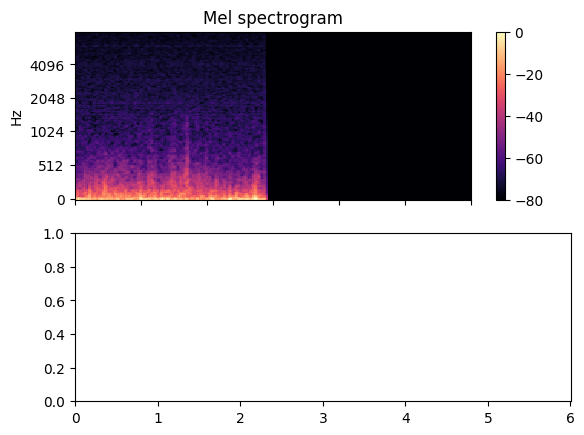

In [21]:
S = lb.feature.melspectrogram(y=signal, sr=sample_rate, n_mels=128,
                                   fmax=8000)

#
fig, ax = plt.subplots(nrows=2, sharex=True)
img = lb.display.specshow(lb.power_to_db(S, ref=np.max),
                               x_axis='time', y_axis='mel', fmax=8000,
                               ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].set(title='Mel spectrogram')
ax[0].label_outer()